In [1]:
import numpy as np
import pandas as pd

In [3]:
np.random.seed(34)

df = pd.DataFrame({
    "age": np.random.randint(18, 65, 300),
    "income": np.random.normal(60000, 12000, 300),
    "experience": np.random.randint(0, 40, 300),
    "spending_score": np.random.normal(50, 15, 300),
    "purchased": np.random.choice([0, 1], 300)
})
df.head()

,age,income,experience,spending_score,purchased
0,51,56124.835765,6,45.826392,0
1,60,53602.182282,26,46.718742,1
2,59,49751.976289,27,37.778620,1
3,39,76530.481506,34,67.346258,1
4,22,58815.563508,26,80.835523,1


### Correlation Matrix
#### Correlation Heatmap

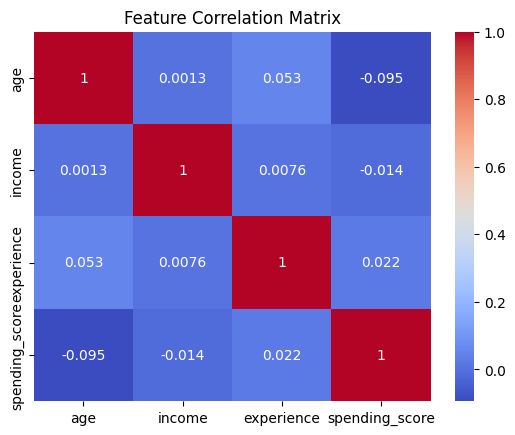

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.drop("purchased", axis=1).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

**ML Interpretation:**
- Detect **clusters of correlated features**
- Spot **redundancy**
- Decide feature removal or regularization

### Pair Plot (Relationship Scanner)

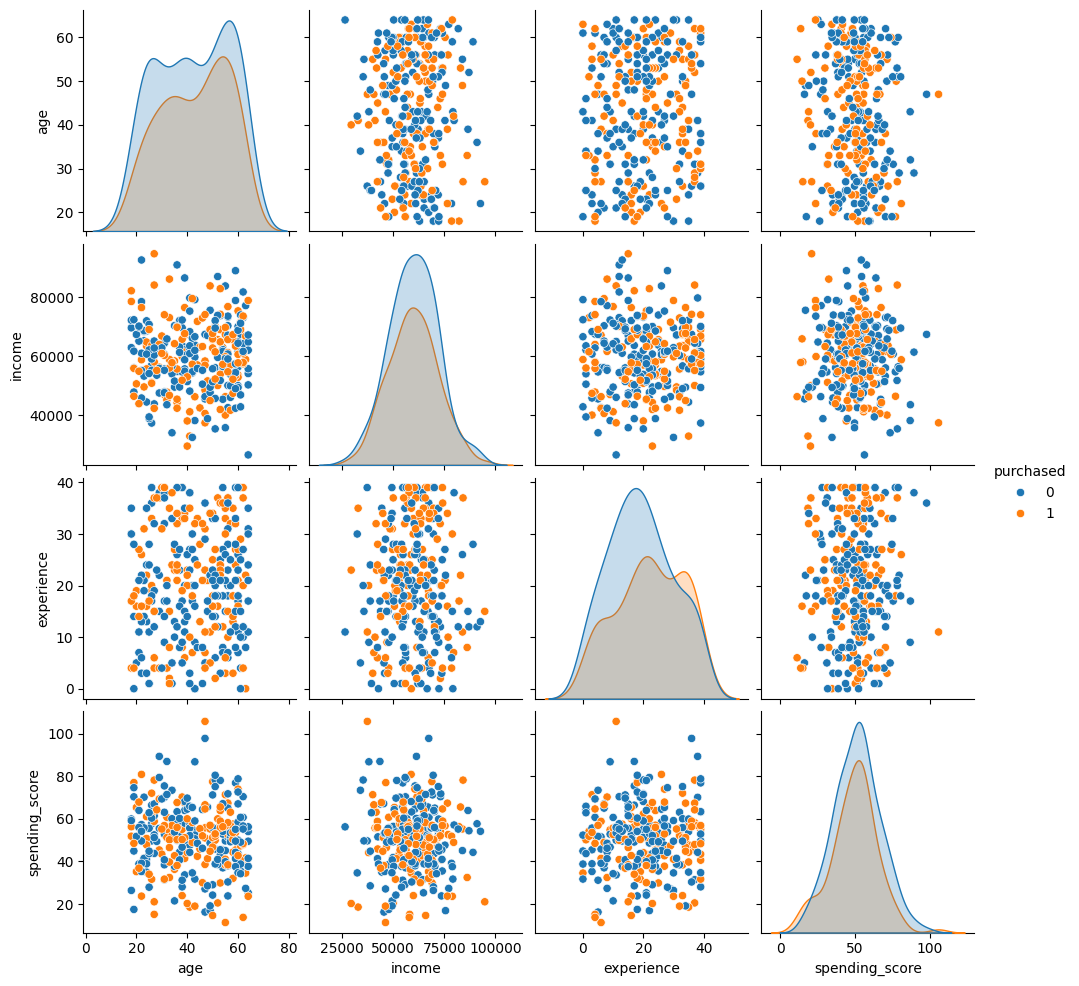

In [5]:
sns.pairplot(df, hue="purchased")
plt.show()

**What Pair Plot Reveals:**
- Linear vs non-linear patterns
- Feature interactions
- Class separability

### Multicollinearity Diagnostics
#### Variance Inflation Factor (VIF)

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop("purchased", axis=1)

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,feature,VIF
0,age,8.504394
1,income,13.288455
2,experience,4.303373
3,spending_score,8.917230


| VIF  | Meaning                  |
| ---- | ------------------------ |
| < 5  | Safe                     |
| 5–10 | Moderate correlation     |
| > 10 | Severe multicollinearity |

### Feature Interaction Detection (Critical for Trees)
**Example: Age + Income -> Purchased**

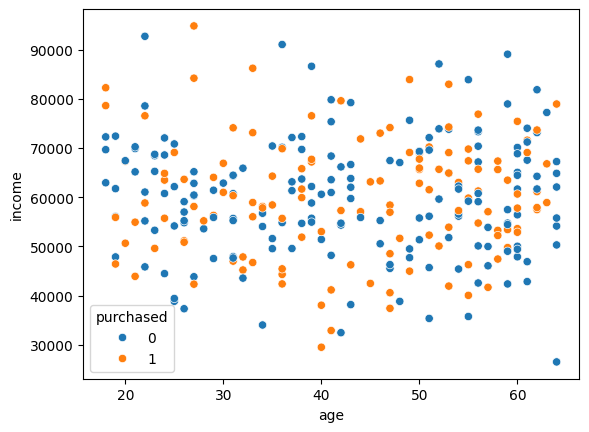

In [9]:
sns.scatterplot(
    x="age",
    y="income",
    hue="purchased",
    data=df
)
plt.show()

**Insight:**
- No clear boundary in 1D
- Clear separation in 2D -> interaction effect

### Dimensionality Intuition
#### Curse of Dimensionality
As features increase:
- Distance metrics break (KNN)
- Sparsity increases
- Noise dominates signal

### Target-Aware Multivariate View

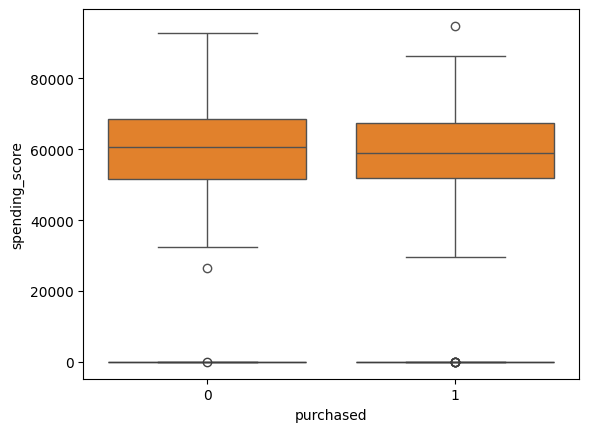

In [16]:
sns.boxplot(
    x="purchased",
    y="spending_score",
    data=df
)
sns.boxplot(
    x="purchased",
    y="income",
    data=df
)
plt.show()

### Mapping to Feature Engineering
| Observation         | Action                     |
| ------------------- | -------------------------- |
| Feature clusters    | Drop or combine            |
| High VIF            | Lasso / Ridge              |
| Interaction visible | Create interaction feature |
| High dimensions     | PCA / feature selection    |
